<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad sintetizar varias señales de distintos tipos, indicando su período, número de muestras y si se trata de una señal de potencia o una de energía. Para eso usaremos el generador de señales que programamos en el trabajo práctico 0.
En la segunda parte de este TP, resolvimos un ejercicio de convolución tomando distintos x(n) y muestreando los resultados.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
#tt: vector de tiempo , xx: vector de señal

fs = 250000
nn = 1000

Los parámetros iniciales elegidos son una amplitud de 1, una frecuencia de muestreo fs que se adaptará a varias señales que sintetizaremos a futuro y un numero de muestras de 1000.

1) En primer lugar sintetizamos una señal de 2000hz:

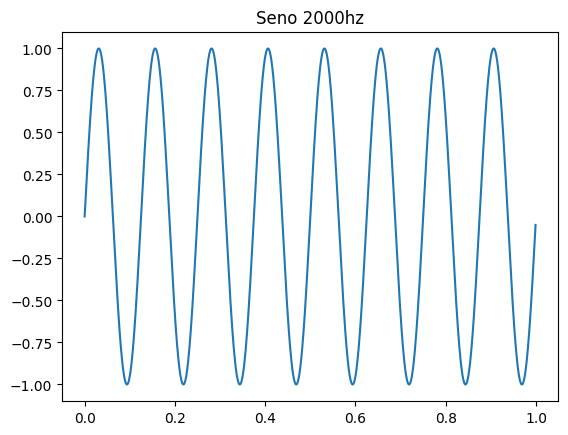

El período es de 4e-06
El numero de muestras es de 1000
Se trata de una señal de potencia


In [34]:
tt, xx = mi_funcion_sen(1 , 0 , 2000 , 0 , nn , fs)
tt = tt*250
plt.figure(1)
plt.plot(tt,xx)
plt.title("Seno 2000hz")
plt.show()

print(f"El período es de {1/fs}")
print(f"El numero de muestras es de {nn}")
print("Se trata de una señal de potencia")

Aqui podemos apreciar la señal de 2000hz con sus respectivos datos, donde encontraremos el período: Ts = 1/fs.
Se trata de una señal de potencia ya que es periódica y está definida para todo tiempo, por lo que tiene energía infinita.

2) Ahora amplificaremos esta señal 3db y la desfasaremos pi/2.
   Para eso, usaremos una formula de ampliación y la despejaremos creando así una funcion.
   
   <img src="formula_ampliacion.png" align="left" width="350" />

Lo que queremos encontrar sería Vout, haciendo el despeje nos queda la siguiente función:

In [35]:
def ampliador_db(v_ini , cant_db):
    
    Ax = v_ini * 10**(cant_db/20)
    
    return Ax

Con esto podemos resolver la consigna.

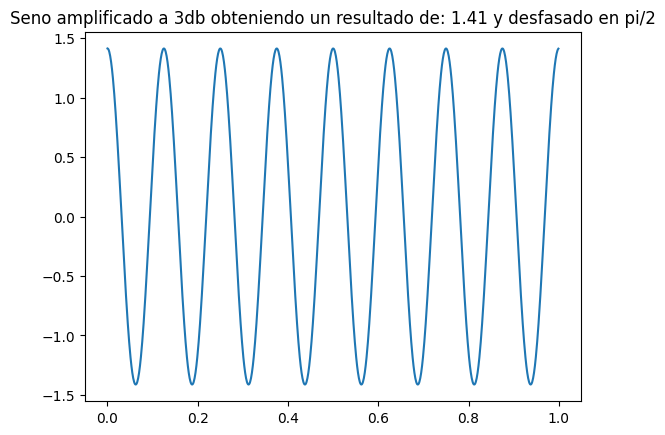

El período es de 4e-06
El numero de muestras es de 1000
Se trata de una señal de potencia


In [36]:
A_3db = ampliador_db(1 , 3)

tt2, xx2 = mi_funcion_sen(A_3db , 0 , 2000 , np.pi/2 , nn , fs)
tt2 = tt2*250
plt.figure(2)
plt.plot(tt2,xx2)
plt.title(f"Seno amplificado a 3db obteniendo un resultado de: {A_3db:.2f} y desfasado en pi/2")
plt.show()

print(f"El período es de {1/fs}")
print(f"El numero de muestras es de {nn}")
print("Se trata de una señal de potencia")

Podemos apreciar a través de los resultados del gráfico que la amplitud aumentó de aproximadamente raiz de 2. Además de que se ve un claro desfasaje con respecto a la primer señal graficada.
Nuevamente se trata de una señal de potencia y los parámetros de período y muestras son exactamente los mismos que los de la primera señal graficada.

3) En esta parte la consigna pide que modulemos en amplitud esta señal por una de frecuencia de 1000 Khz, o sea 1.000.000hz. Lo que es extraño en este enunciado es que la señal moduladora es mucho mayor que la portadora, por lo que debería afectar el resultado. Tendría mucho sentido usar una señal moduladora de 1000hz y es por esto que usaremos una frecuencia de 1Khz asumiendo que se trata de un error en el enunciado.
   Para resolver esta parte usamos los apuntes que tomamos de la clase que nos dió el docente: (el +1 no forma parte de la señal moduladora)

   <img src="Modulacion.png" align="left" width="750" />
   
   

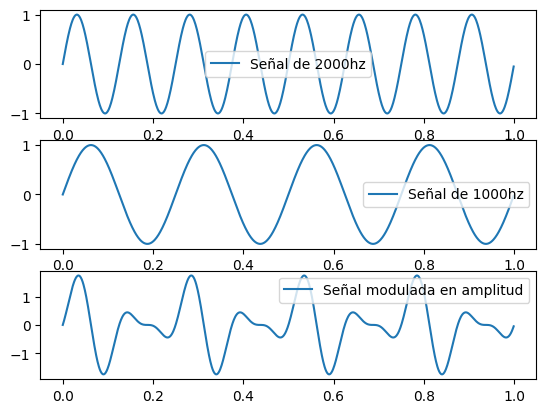

El período es de 4e-06
El numero de muestras es de 1000
Se trata de una señal de potencia


In [37]:
##señal de 1000hz:
tt3, xx3 = mi_funcion_sen(1 , 0 , 1000 , 0 , nn , fs)
tt3 = tt3*250

#xx es la señal usada en la parte 1
xx_mod = xx * (1 + xx3)

plt.figure(3)
plt.subplot(3,1,1)
plt.plot(tt, xx, label = 'Señal de 2000hz')
plt.legend()
plt.subplot(3,1,2)
plt.plot(tt3, xx3, label = 'Señal de 1000hz')
plt.legend()
plt.subplot(3,1,3)
plt.plot(tt3,xx_mod, label = 'Señal modulada en amplitud')
plt.legend()
plt.show()

print(f"El período es de {1/fs}")
print(f"El numero de muestras es de {nn}")
print("Se trata de una señal de potencia")

Podemos observar que habiendo hecho los cambios mencionados anteriormente obtuvimos un resultado donde se ve que la señal moduladora afecta la amplitud de la inicial debido a que tiene una oscilación interna de menor frecuencia. 
Y claramente se trata de una señal de potencia debido a que es producto de una modulación de 2 señales de potencia.

4) Ahora le agregaremos a la señal inicial un efecto de saturación del 75% de su amplitud.
   Para esto usaremos numpy.clip(), que es una funcion que limita los parámetros solicitados, en este caso la amplitud.

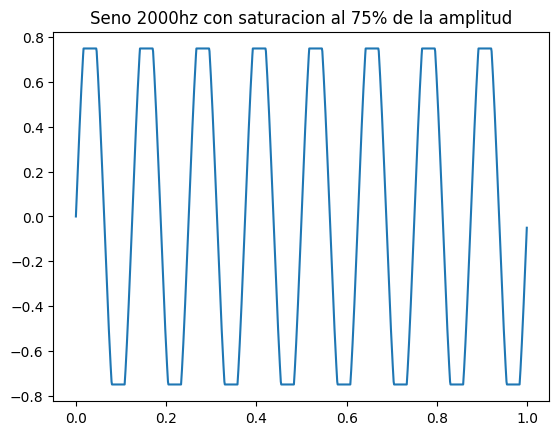

El período es de 4e-06
El numero de muestras es de 1000
Se trata de una señal de potencia


In [38]:
xx_clipped = np.clip(xx , -0.75 , 0.75)

plt.figure(4)
plt.plot(tt,xx_clipped)
plt.title("Seno 2000hz con saturacion al 75% de la amplitud")
plt.show()

print(f"El período es de {1/fs}")
print(f"El numero de muestras es de {nn}")
print("Se trata de una señal de potencia")

Se puede apreciar como en el gráfico no se dibuja ninguna amplitud mayor a 0.75, lo que nos deja con ese efecto rectangular cada vez que se alcanza este valor.

5) A continuación graficaremos una señal cuadrada de 4Khz.
   Para hacer esto simplemente usaremos la funcion numpy.sign(), que consiste en devolver -1 si x < 0, 0 si x==0, 1 si x > 0. Lo que nos va a dar solamente 2 valores cada vez que la senoidal sea distinta de 0, dandonos el efecto de cuadrado.

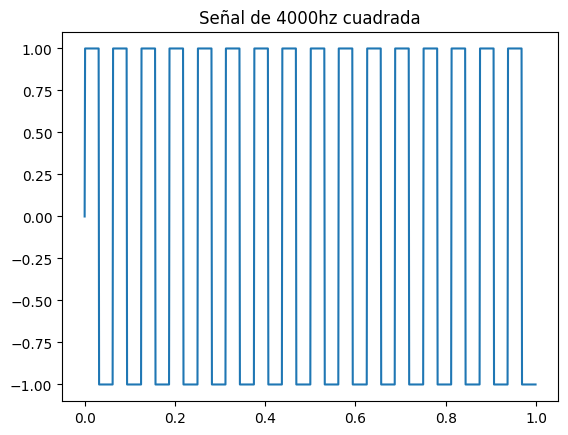

El período es de 4e-06
El numero de muestras es de 1000
Se trata de una señal de potencia


In [39]:
tt4, xx4 = mi_funcion_sen(1 , 0 , 4000 , 0 , nn , fs)
tt4 = tt4*250
xx4_cuadrada = np.sign(xx4)

plt.figure(5)
plt.plot(tt,xx4_cuadrada)
plt.title("Señal de 4000hz cuadrada")
plt.show()

print(f"El período es de {1/fs}")
print(f"El numero de muestras es de {nn}")
print("Se trata de una señal de potencia")

6) Para concluir con la primera parte de este TP, generaremos un pulso rectangular de 10ms. 
    Para esto usaremos numpy.where(), que consiste en devolvernos un array de valores siempre y cuando se cumpla cierto parámetro, en este caso sería que el tiempo sea menor o igual a 10ms y el valor que sería devuelto es la amplitud, en este caso 1. En caso de que no se cumpla esa condición, el array será de 0.

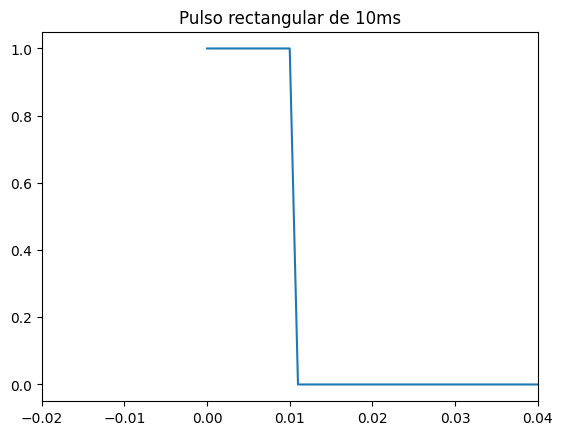

Se trata de una señal de energía


In [40]:
x_time = np.where(tt < 0.01 , 1 , 0)

plt.figure(6)
plt.xlim(-0.02 , 0.04)
plt.plot(tt,x_time)
plt.title("Pulso rectangular de 10ms")
plt.show()

print("Se trata de una señal de energía")

Podemos observar que antes del 0 no se dibuja nada debido a que tt empieza en 0, entre el 0 y los 10 ms se dibuja una linea horizontal de amplitud 1 ya que cumple con las condiciones establecidas. Finalmente el valor decae a 0 llegados los 10ms. Usamos plt.xlim() para que el gráfico se aprecie mejor.
Se trata de una señal de energía ya que tiene duración finita por lo que la energía total es finita.

En la segunda parte de este trabajo se nos pide resolver unos ejercicios de convolución donde:

h(n) = $\delta$(n) - $\delta$(n - 4)

Hay que encontrar y(n) que cumpla:

y(n) = x(n) * h(n)  para cada x(n)

Para resolver esto usaremos la propiedad que dice que la convolucion de una función con una delta desplazada, resulta en esa misma función desplazada, o sea:
x(n) * $\delta$(n - k) = x(n - k)

O sea que y(n) = x(n) - x(n - 4)


1) x(n) = cos(w0.n.Ts)   expresado de la forma: A.cos(w0.n.Ts + $\varphi$)

   A continuación se puede observar la resolución con todas las propiedades trigonométricas empleadas expresar el resultado en el formato esperado:

<img src="coseno.jpeg" align="left" width="750" />

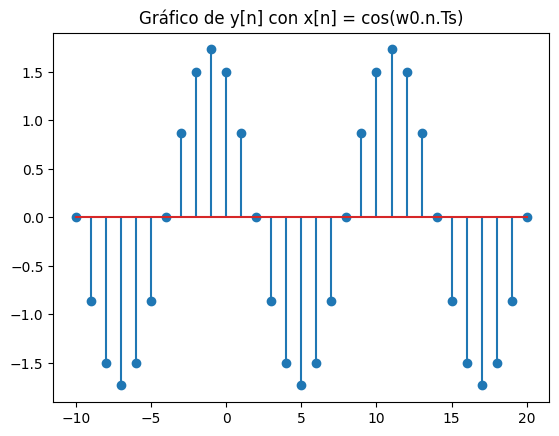

In [41]:
w0 = np.pi/6
n = np.arange(-10,21,1)
Ts = 1

y1 = np.cos(w0 * n *Ts) - np.cos(w0 * (n-4) * Ts) 

plt.figure()
plt.stem(n , y1)
plt.title('Gráfico de y[n] con x[n] = cos(w0.n.Ts)')
plt.show()

Acá podemos ver el gráfico de esta función para diferentes n. Los parámetros elegidos para w0, n y Ts fueron elegidos para que el gráfico se vea correctamente. Se usó plt.stem() para visualizar la señal discreta, devolviéndonos varios valores con la forma de un cosenoidal.

2) x(n) = $(1/2)^n$.u(n)

   u(n) sería la función escalón unitario

   <img src="u(n).jpeg" align="left" width="750" />

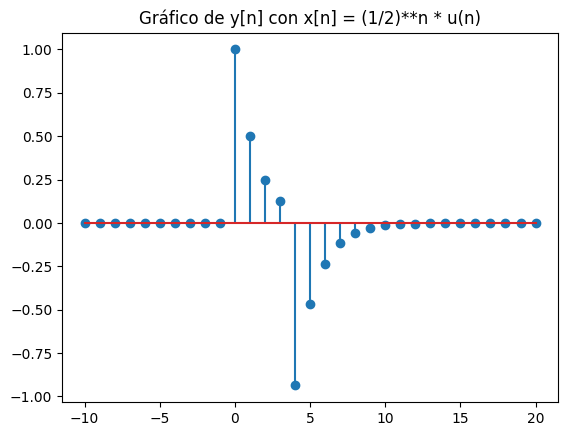

In [42]:
def u(n):
    return np.where(n>= 0, 1, 0)

y2 = (1/2)**n * u(n) - (1/2)**(n-4) * u(n - 4)

plt.figure()
plt.stem(n , y2)
plt.title('Gráfico de y[n] con x[n] = (1/2)**n * u(n)')
plt.show()

En el gráfico podemos observar que los valores no están solamente en 1 o 0 debido a que 1/2 está elevado a la n, además se aprecia que a partir del 4 el gráfico es negativo debido a que se le resta el u(n - 4). Se puede observar que antes del 0 los valores son 0 y a partir aproximadamente del 10 los valores decaen infinitamente cerca del 0.

3) x(n) = u(n + 1) - u(n - 2)
   <img src="cajitas.jpeg" align="left" width="750" />

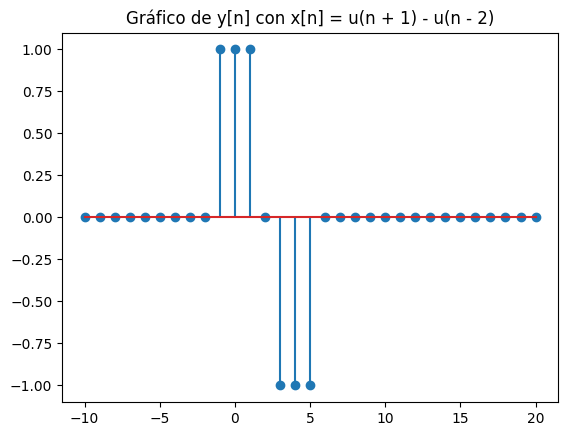

In [43]:
y3 = u(n + 1) - u(n - 2) - u(n - 3) + u(n - 6)

plt.figure()
plt.stem(n , y3)
plt.title('Gráfico de y[n] con x[n] = u(n + 1) - u(n - 2)')
plt.show()


En este gráfico podemos observar 2 cajitas.
La primera comienza en n=-1 por u(n+1) y en n=2 se cancela volviendose 0 por el -u(n-2).
La segunda comienza en n=3, teniendo valores negativos por -u(n-3), finalmente en n=6 vuelve a ser 0 debido a que se cancela con u(n-6).

En este trabajo práctico aprendimos muchos métodos de como sintetizar distintos tipos de señales y modificarlas, interpretando sus resultados. También realizamos varios ejercicios de convolución, graficando sus resultados mediante una señal discreta y analizándolos.